In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sn

In [4]:
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
df = pd.read_csv('/kaggle/input/datasets/vikasukani/diabetes-data-set/diabetes-dataset.csv',header = None,skiprows=1,names=col_names)
print(df.head())

   pregnant  glucose  bp  skin  insulin   bmi  pedigree  age  label
0         2      138  62    35        0  33.6     0.127   47      1
1         0       84  82    31      125  38.2     0.233   23      0
2         0      145   0     0        0  44.2     0.630   31      1
3         0      135  68    42      250  42.3     0.365   24      1
4         1      139  62    41      480  40.7     0.536   21      0


In [5]:
print(df.columns)
df.isnull().sum()

Index(['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree',
       'age', 'label'],
      dtype='object')


pregnant    0
glucose     0
bp          0
skin        0
insulin     0
bmi         0
pedigree    0
age         0
label       0
dtype: int64

In [6]:
feat_cols = ['pregnant','insulin','bmi','age','glucose','bp','pedigree']
x=df[feat_cols]
y=df.label

      pregnant  insulin   bmi  age  glucose   bp  pedigree
0            2        0  33.6   47      138   62     0.127
1            0      125  38.2   23       84   82     0.233
2            0        0  44.2   31      145    0     0.630
3            0      250  42.3   24      135   68     0.365
4            1      480  40.7   21      139   62     0.536
...        ...      ...   ...  ...      ...  ...       ...
1995         2       55  29.7   33       75   64     0.370
1996         8      130  32.7   36      179   72     0.719
1997         6        0  31.2   42       85   78     0.382
1998         0      130  67.1   26      129  110     0.319
1999         2       76  30.1   25       81   72     0.547

[2000 rows x 7 columns]
0       1
1       0
2       1
3       1
4       0
       ..
1995    0
1996    1
1997    0
1998    1
1999    0
Name: label, Length: 2000, dtype: int64


In [7]:
x_tr, x_te, y_tr, y_te = train_test_split(x,y,test_size=0.2,random_state=5)
display(x_tr.shape,y_tr.shape,x_te.shape,y_te.shape)

(1600, 7)

(1600,)

(400, 7)

(400,)

In [8]:
mdl = LogisticRegression(solver='lbfgs',max_iter=1000)

In [9]:
mdl.fit(x_tr, y_tr)
y_pred = mdl.predict(x_te)

In [10]:
conf_mat = metrics.confusion_matrix(y_te,y_pred)
print("Confusion Matrix: ",conf_mat)
acc_score = metrics.accuracy_score(y_te,y_pred)
print("Accuracy: ",acc_score)
print("Accuracy in percent: ",int(acc_score*100),'%')

Confusion Matrix:  [[239  30]
 [ 46  85]]
Accuracy:  0.81
Accuracy in percent:  81 %


<Axes: xlabel='Predicted', ylabel='Actual'>

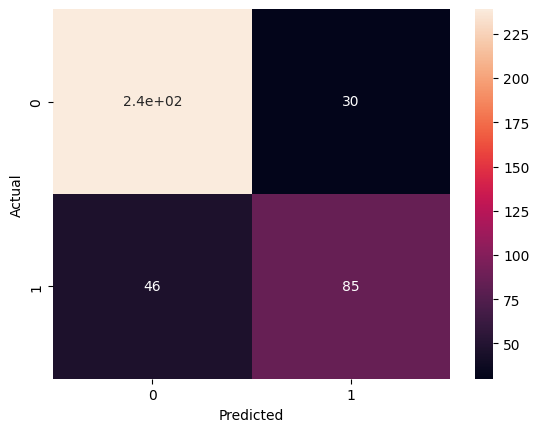

In [11]:
conf_mat = pd.crosstab(y_te, y_pred, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(conf_mat, annot=True)